
# Validación Cruzada para Clasificación - Burnout

**Validación cruzada en clasficación:** muestreo estratificado

**cv** = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cross_validate(model, X, Y, cv=cv, scoring=('f1_macro', 'accuracy','precision_macro', 'recall_macro'), return_train_score=True)

**Objetivo del modelo:** predecir la variable `burnout_risk`. Como tiene tres categorías (`Low`, `Medium`, `High`), el problema se trabaja como clasificación multiclase.


In [1]:
#Cargamos librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. Preparación de Datos


In [2]:
#Cargamos los datos
data = pd.read_csv("datos_limpios_burnout.csv")
data.head()


,work_hours,meetings_count,task_completion_rate,burnout_score,burnout_risk
0,9.59,4,91.2,19.17,Low
1,7.38,4,82.0,29.70,Low
2,6.31,1,80.6,32.93,Low
3,8.34,4,70.0,45.47,Low
4,6.97,1,67.1,51.61,Low


In [3]:
#Conocemos los datos
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   work_hours            1800 non-null   float64
 1   meetings_count        1800 non-null   int64  
 2   task_completion_rate  1800 non-null   float64
 3   burnout_score         1800 non-null   float64
 4   burnout_risk          1800 non-null   object 
dtypes: float64(3), int64(1), object(1)
memory usage: 70.4+ KB


In [4]:
#Corrección de tipos de datos

data['burnout_risk']=data['burnout_risk'].astype('category')
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   work_hours            1800 non-null   float64 
 1   meetings_count        1800 non-null   int64   
 2   task_completion_rate  1800 non-null   float64 
 3   burnout_score         1800 non-null   float64 
 4   burnout_risk          1800 non-null   category
dtypes: category(1), float64(3), int64(1)
memory usage: 58.3 KB


In [5]:
#Descripción de variables numéricas
data.describe()


,work_hours,meetings_count,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000
mean,6.515117,1.941111,72.141117,42.541480
std,2.290521,1.696178,14.809168,21.561686
min,3.000000,0.000000,40.000000,2.500000
25%,4.430000,1.000000,62.300000,25.370000
50%,6.445000,2.000000,74.300000,39.270000
75%,8.510000,3.000000,83.600000,56.110000
max,12.170000,10.000000,100.000000,99.690000


<Axes: >

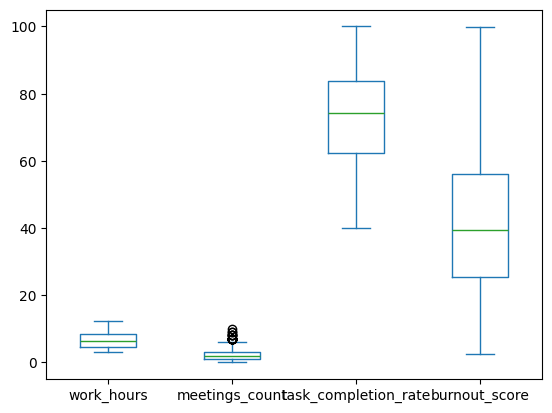

In [6]:
data.plot(kind='box')


<Axes: xlabel='burnout_risk'>

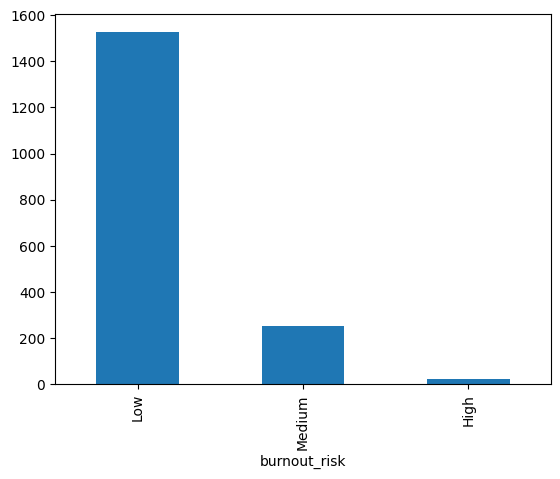

In [7]:
#Descripción variables categóricas
data['burnout_risk'].value_counts().plot(kind='bar')


# **Diagnóstico inicial para minería de datos**

La variable objetivo `burnout_risk` está desbalanceada porque la clase `Low` tiene la mayor cantidad de registros, mientras que `High` tiene pocos casos. Por esta razón, para comparar los modelos se usa `f1_macro`, ya que permite evaluar las clases de forma más equilibrada que la exactitud general.


In [8]:
#Configuración de variables
objetivo='burnout_risk'
predictoras_numericas=['work_hours','meetings_count','task_completion_rate','burnout_score']
predictoras_categoricas_2cat=[]
predictoras_categoricas_multicat=[]


In [9]:
#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data[objetivo] = labelencoder.fit_transform(data[objetivo])
data.head()


,work_hours,meetings_count,task_completion_rate,burnout_score,burnout_risk
0,9.59,4,91.2,19.17,1
1,7.38,4,82.0,29.70,1
2,6.31,1,80.6,32.93,1
3,8.34,4,70.0,45.47,1
4,6.97,1,67.1,51.61,1


['High' 'Low' 'Medium']


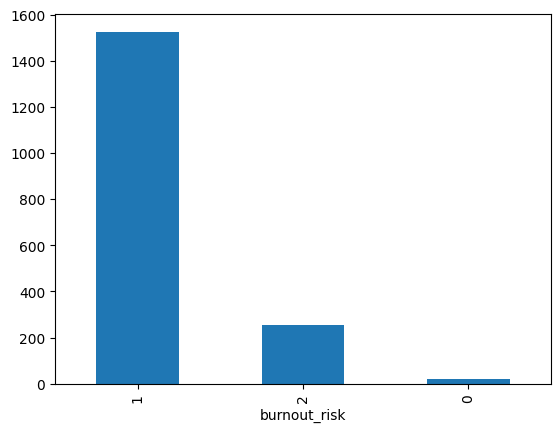

In [10]:
#Descripción variables categóricas
data[objetivo].value_counts().plot(kind='bar')
print(labelencoder.classes_)


# 2. Validación Cruzada


In [11]:
#Validación Cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold

#Dataframe para comparar los modelos
comparacion_CV=pd.DataFrame()
scoring=('f1_macro', 'accuracy','precision_macro', 'recall_macro')
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) #Muestreo estratificado


In [12]:
#Se separa variables predictoras y objetivo
X = data.drop(objetivo, axis = 1)
Y = data[objetivo]
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   work_hours            1800 non-null   float64
 1   meetings_count        1800 non-null   int64  
 2   task_completion_rate  1800 non-null   float64
 3   burnout_score         1800 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 56.4 KB


# **Árbol de Decisión**


In [13]:
#Tree
from sklearn import tree
modelTree = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=10, max_depth=10, random_state=3)

scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores


,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.004568,0.007375,0.882353,0.923551,0.994444,0.994444,0.987179,0.891825,0.833333,0.969786
1,0.007068,0.006464,0.750000,0.923951,0.977778,0.995062,0.735507,0.912242,0.793333,0.937135
2,0.003621,0.006569,0.866527,0.920177,0.983333,0.994444,0.831169,0.895561,0.960000,0.952729
3,0.002961,0.005826,1.000000,0.906562,1.000000,0.993210,1.000000,0.876983,1.000000,0.949805
4,0.002977,0.006018,1.000000,0.913228,1.000000,0.993827,1.000000,0.885886,1.000000,0.951267
5,0.003467,0.006365,0.926531,0.920177,0.994444,0.994444,0.888889,0.895561,0.986667,0.952729
6,0.002885,0.005039,1.000000,0.913228,1.000000,0.993827,1.000000,0.885886,1.000000,0.951267
7,0.002499,0.005080,0.773259,0.916425,0.977778,0.994444,0.752137,0.900298,0.805499,0.935634
8,0.002490,0.005644,0.926797,0.902403,0.994444,0.993210,0.888889,0.879553,0.987179,0.932697
9,0.003137,0.005624,0.820513,0.920148,0.988889,0.994444,0.820513,0.895548,0.820513,0.952684


In [14]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

#Cuidado overfitting, más de 5 puntos de diferencia


fit_time                 0.003567
score_time               0.006000
test_f1_macro            0.894598
train_f1_macro           0.915985
test_accuracy            0.991111
train_accuracy           0.994136
test_precision_macro     0.890428
train_precision_macro    0.891934
test_recall_macro        0.918652
train_recall_macro       0.948573
dtype: float64

In [15]:
#Se almacena en el df la medida a comparar
comparacion_CV['Tree']=scores['test_f1_macro']
comparacion_CV


,Tree
0,0.882353
1,0.750000
2,0.866527
3,1.000000
4,1.000000
5,0.926531
6,1.000000
7,0.773259
8,0.926797
9,0.820513


# **Random Forest**


In [16]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=200,  max_samples=0.8, criterion='gini',
                              max_depth=5, min_samples_leaf=20, random_state=3)

scores = cross_validate(model_rf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores


/home/fu11shoot/Descargas/AnaliticaPython2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fu11shoot/Descargas/AnaliticaPython2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fu11shoot/Descargas/AnaliticaPython2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.245207,0.018937,0.653846,0.654008,0.988889,0.988889,0.641975,0.642276,0.666667,0.666667
1,0.253317,0.017644,0.804348,0.901783,0.977778,0.991975,0.777778,0.860215,0.946667,0.980994
2,0.248276,0.019457,0.653846,0.718128,0.988889,0.989506,0.641975,0.866941,0.666667,0.702242
3,0.207495,0.014534,0.653846,0.654008,0.988889,0.988889,0.641975,0.642276,0.666667,0.666667
4,0.199667,0.014417,0.653846,0.751289,0.988889,0.990741,0.641975,0.979424,0.666667,0.722222
5,0.201496,0.015111,0.653846,0.654008,0.988889,0.988889,0.641975,0.642276,0.666667,0.666667
6,0.200977,0.015532,0.653846,0.654008,0.988889,0.988889,0.641975,0.642276,0.666667,0.666667
7,0.253684,0.017147,0.627105,0.872963,0.966667,0.991358,0.628205,0.856163,0.626012,0.894192
8,0.234375,0.014441,0.882600,0.751244,0.994444,0.990741,0.987654,0.979339,0.833333,0.722222
9,0.206277,0.017764,0.654321,0.653955,0.988889,0.988889,0.642857,0.642177,0.666667,0.666667


In [17]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()


fit_time                 0.225077
score_time               0.016498
test_f1_macro            0.689145
train_f1_macro           0.726539
test_accuracy            0.986111
train_accuracy           0.989877
test_precision_macro     0.688835
train_precision_macro    0.775336
test_recall_macro        0.707268
train_recall_macro       0.735521
dtype: float64

In [18]:
#Se almacena en el df la medida a comparar
comparacion_CV['RF']=scores['test_f1_macro']
comparacion_CV


,Tree,RF
0,0.882353,0.653846
1,0.750000,0.804348
2,0.866527,0.653846
3,1.000000,0.653846
4,1.000000,0.653846
5,0.926531,0.653846
6,1.000000,0.653846
7,0.773259,0.627105
8,0.926797,0.882600
9,0.820513,0.654321


# **KNN**


In [19]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

X_norm = X.copy()
min_max_scaler.fit(X_norm[predictoras_numericas]) #Ajuste de los parametros: max - min
X_norm[predictoras_numericas]= min_max_scaler.transform(X_norm[predictoras_numericas])
X_norm.head()


,work_hours,meetings_count,task_completion_rate,burnout_score
0,0.718648,0.4,0.853333,0.171520
1,0.477644,0.4,0.700000,0.279864
2,0.360960,0.1,0.676667,0.313098
3,0.582334,0.4,0.500000,0.442124
4,0.432933,0.1,0.451667,0.505299


In [20]:
#Método Perezoso
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=21, metric='euclidean')

scores = cross_validate(model_knn, X_norm, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores


,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.003767,0.011355,0.851852,0.799624,0.972222,0.977160,0.957181,0.857784,0.802309,0.761943
1,0.003862,0.012651,0.755076,0.836555,0.966667,0.975926,0.744463,0.845346,0.777821,0.829684
2,0.002280,0.008218,0.866316,0.810976,0.983333,0.976543,0.981810,0.853243,0.806667,0.778757
3,0.002805,0.008664,0.841828,0.760837,0.966667,0.978395,0.962467,0.810993,0.777821,0.731973
4,0.002456,0.008299,0.801227,0.836077,0.972222,0.976543,0.812389,0.838101,0.791155,0.834804
5,0.001974,0.006880,0.863311,0.805357,0.977778,0.976543,0.991507,0.835206,0.793333,0.781195
6,0.002277,0.007226,0.626905,0.846049,0.966667,0.978395,0.643023,0.841570,0.613333,0.853808
7,0.002110,0.007335,0.629374,0.852329,0.961111,0.975309,0.647817,0.857156,0.613192,0.848770
8,0.002042,0.006559,0.801227,0.829697,0.972222,0.975926,0.824786,0.830678,0.782051,0.830737
9,0.002681,0.006904,0.867388,0.859870,0.983333,0.976543,0.831155,0.871693,0.961538,0.849255


In [21]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()


fit_time                 0.002625
score_time               0.008409
test_f1_macro            0.790450
train_f1_macro           0.823737
test_accuracy            0.972222
train_accuracy           0.976728
test_precision_macro     0.839660
train_precision_macro    0.844177
test_recall_macro        0.771922
train_recall_macro       0.810093
dtype: float64

In [22]:
#Se almacena en el df la medida a comparar
comparacion_CV['Knn']=scores['test_f1_macro']
comparacion_CV


,Tree,RF,Knn
0,0.882353,0.653846,0.851852
1,0.750000,0.804348,0.755076
2,0.866527,0.653846,0.866316
3,1.000000,0.653846,0.841828
4,1.000000,0.653846,0.801227
5,0.926531,0.653846,0.863311
6,1.000000,0.653846,0.626905
7,0.773259,0.627105,0.629374
8,0.926797,0.882600,0.801227
9,0.820513,0.654321,0.867388


# **Red Neuronal**


In [23]:
#Red neuronal

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios
from sklearn.neural_network import MLPClassifier
model_rn = MLPClassifier(activation="logistic",hidden_layer_sizes=(50), learning_rate='constant',
                     learning_rate_init=0.02, momentum= 0.03, max_iter=500, random_state=3)

scores = cross_validate(model_rn, X_norm, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores


/home/fu11shoot/Descargas/AnaliticaPython2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fu11shoot/Descargas/AnaliticaPython2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fu11shoot/Descargas/AnaliticaPython2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.190693,0.007533,0.617177,0.632950,0.961111,0.972840,0.602757,0.619256,0.633464,0.648165
1,0.200457,0.007466,0.733932,0.879218,0.966667,0.976543,0.718836,0.862267,0.777821,0.904249
2,0.262899,0.005673,0.926531,0.858364,0.994444,0.974074,0.888889,0.819918,0.986667,0.936173
3,0.219516,0.006151,0.960558,0.858470,0.972222,0.974691,0.965729,0.821100,0.955643,0.949814
4,0.216016,0.006641,0.780285,0.809940,0.961111,0.975309,0.785173,0.803641,0.775643,0.817262
5,0.247922,0.007095,0.867828,0.802407,0.983333,0.972840,0.964286,0.790559,0.828976,0.816292
6,0.215778,0.006552,0.620699,0.847199,0.966667,0.977778,0.629189,0.852146,0.613333,0.842605
7,0.262499,0.005860,0.713946,0.879511,0.961111,0.977778,0.693333,0.845447,0.777665,0.930200
8,0.236248,0.007018,0.765127,0.834598,0.972222,0.974691,0.748918,0.812388,0.792679,0.868030
9,0.222036,0.008478,0.984987,0.805019,0.988889,0.974691,0.984987,0.810492,0.984987,0.799830


In [24]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()


fit_time                 0.227406
score_time               0.006847
test_f1_macro            0.797107
train_f1_macro           0.820768
test_accuracy            0.972778
train_accuracy           0.975123
test_precision_macro     0.798210
train_precision_macro    0.803721
test_recall_macro        0.812688
train_recall_macro       0.851262
dtype: float64

In [25]:
#Se almacena en el df la medida a comparar
comparacion_CV['NN']=scores['test_f1_macro']
comparacion_CV


,Tree,RF,Knn,NN
0,0.882353,0.653846,0.851852,0.617177
1,0.750000,0.804348,0.755076,0.733932
2,0.866527,0.653846,0.866316,0.926531
3,1.000000,0.653846,0.841828,0.960558
4,1.000000,0.653846,0.801227,0.780285
5,0.926531,0.653846,0.863311,0.867828
6,1.000000,0.653846,0.626905,0.620699
7,0.773259,0.627105,0.629374,0.713946
8,0.926797,0.882600,0.801227,0.765127
9,0.820513,0.654321,0.867388,0.984987


# **SVM**


In [26]:
#SVM
from sklearn.svm import SVC # SVR
model_svm=SVC(kernel='linear', C=0.8)

scores = cross_validate(model_svm, X_norm, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores


/home/fu11shoot/Descargas/AnaliticaPython2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fu11shoot/Descargas/AnaliticaPython2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fu11shoot/Descargas/AnaliticaPython2/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,0.006160,0.007777,0.623848,0.634742,0.966667,0.974691,0.612927,0.625938,0.635643,0.644015
1,0.009236,0.007929,0.646706,0.633847,0.983333,0.974074,0.630952,0.625543,0.664488,0.642553
2,0.009310,0.007225,0.653846,0.632181,0.988889,0.972840,0.641975,0.623913,0.666667,0.640849
3,0.007171,0.005627,0.615486,0.633972,0.961111,0.974074,0.608891,0.624713,0.622309,0.643773
4,0.007719,0.007811,0.615486,0.635633,0.961111,0.975309,0.608891,0.626332,0.622309,0.645477
5,0.007494,0.007626,0.623848,0.633972,0.966667,0.974074,0.612927,0.624713,0.635643,0.643773
6,0.008030,0.006817,0.620699,0.634984,0.966667,0.974691,0.629189,0.624302,0.613333,0.646454
7,0.006725,0.005886,0.820513,0.663008,0.988889,0.972222,0.820513,0.734936,0.820513,0.657555
8,0.007884,0.007947,0.639782,0.632950,0.977778,0.973457,0.628759,0.624155,0.651653,0.642216
9,0.007077,0.008804,0.639782,0.632950,0.977778,0.973457,0.628759,0.624155,0.651653,0.642216


In [27]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()


fit_time                 0.007680
score_time               0.007345
test_f1_macro            0.650000
train_f1_macro           0.636824
test_accuracy            0.973889
train_accuracy           0.973889
test_precision_macro     0.642378
train_precision_macro    0.635870
test_recall_macro        0.658421
train_recall_macro       0.644888
dtype: float64

In [28]:
#Se almacena en el df la medida a comparar
comparacion_CV['SVM']=scores['test_f1_macro']
comparacion_CV


,Tree,RF,Knn,NN,SVM
0,0.882353,0.653846,0.851852,0.617177,0.623848
1,0.750000,0.804348,0.755076,0.733932,0.646706
2,0.866527,0.653846,0.866316,0.926531,0.653846
3,1.000000,0.653846,0.841828,0.960558,0.615486
4,1.000000,0.653846,0.801227,0.780285,0.615486
5,0.926531,0.653846,0.863311,0.867828,0.623848
6,1.000000,0.653846,0.626905,0.620699,0.620699
7,0.773259,0.627105,0.629374,0.713946,0.820513
8,0.926797,0.882600,0.801227,0.765127,0.639782
9,0.820513,0.654321,0.867388,0.984987,0.639782


# 3. Comparación de modelos


In [29]:
comparacion_CV


,Tree,RF,Knn,NN,SVM
0,0.882353,0.653846,0.851852,0.617177,0.623848
1,0.750000,0.804348,0.755076,0.733932,0.646706
2,0.866527,0.653846,0.866316,0.926531,0.653846
3,1.000000,0.653846,0.841828,0.960558,0.615486
4,1.000000,0.653846,0.801227,0.780285,0.615486
5,0.926531,0.653846,0.863311,0.867828,0.623848
6,1.000000,0.653846,0.626905,0.620699,0.620699
7,0.773259,0.627105,0.629374,0.713946,0.820513
8,0.926797,0.882600,0.801227,0.765127,0.639782
9,0.820513,0.654321,0.867388,0.984987,0.639782


<Axes: >

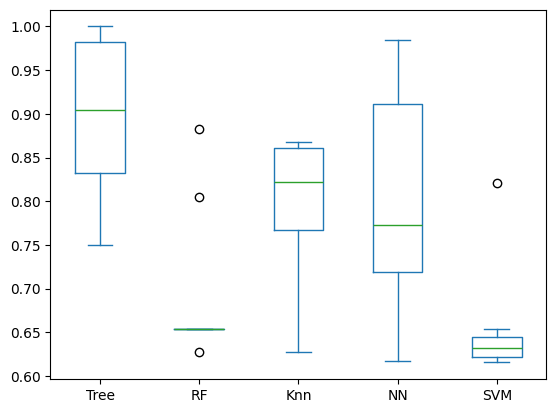

In [30]:
#Resultados de la validación cruzada
comparacion_CV.plot(kind='box')


In [31]:
#Promedio de f1_macro para seleccionar el mejor modelo
promedios_modelos = comparacion_CV.mean().sort_values(ascending=False)
promedios_modelos


Tree    0.894598
NN      0.797107
Knn     0.790450
RF      0.689145
SVM     0.650000
dtype: float64

# **Conclusiones de los modelos**

Según la validación cruzada, el modelo con mejor calidad general es el Árbol de Decisión, con `test_f1_macro` promedio de 0.8946. Luego se ubican Red Neuronal con 0.7971, KNN con 0.7905, Random Forest con 0.6891 y SVM con 0.6500.

La métrica principal es `f1_macro` porque la variable objetivo está desbalanceada y se requiere evaluar las clases `Low`, `Medium` y `High` sin que la clase mayoritaria domine la evaluación. La exactitud es alta en varios modelos, pero no se usa como criterio principal porque puede ocultar bajo desempeño en las clases minoritarias.

Al comparar las medidas de entrenamiento y prueba, ningún modelo queda con una diferencia mayor a 5 puntos en `f1_macro`: Árbol tiene una diferencia aproximada de 0.0214, Random Forest de 0.0374, KNN de 0.0333, Red Neuronal de 0.0237 y SVM no presenta diferencia positiva de entrenamiento sobre prueba. Por lo tanto, no se evidencia overfitting fuerte en la configuración final.

Tampoco se evidencia underfitting en el modelo seleccionado, porque el Árbol mantiene buen desempeño tanto en entrenamiento como en prueba. SVM y Random Forest tienen menor calidad relativa en `f1_macro`, pero se conservan en el notebook porque hacen parte de las técnicas solicitadas. El Árbol de Decisión se selecciona para hiperparametrización porque obtiene el mejor promedio de `f1_macro`, presenta buen comportamiento entre entrenamiento y prueba, y además es interpretable para explicar el riesgo de burnout.


# 4. Hiperparametrización con GridSearchCV


In [32]:
#Hiperparametrización
from sklearn.model_selection import GridSearchCV

scoring='f1_macro'
cv=10

#Dataframe para comparar modelos
medidas_CV= pd.DataFrame(index=['F1_macro'])


In [33]:
#  Arbol
from sklearn.tree import DecisionTreeClassifier
modelTree = DecisionTreeClassifier(random_state=3)

# Definir los hiperparametros
criterion=['gini','entropy'] #Indice de información
min_samples_leaf=[2,5,10,20,50] # Cantidad de registros por hoja
max_depth=[2,3,5,10,20] #Niveles de profundidad

param_grid = dict(criterion=criterion, min_samples_leaf=min_samples_leaf, max_depth=max_depth)
grid = GridSearchCV(estimator=modelTree, param_grid=param_grid, scoring=scoring, n_jobs=-1, cv=cv)
grid.fit(X, Y)#70%

#Mejor modelo
modelTree= grid.best_estimator_
print( grid.best_params_)

#Dataframes de medidas
medidas_CV['Tree']=grid.best_score_
print(medidas_CV)


{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 2}
              Tree
F1_macro  0.905863


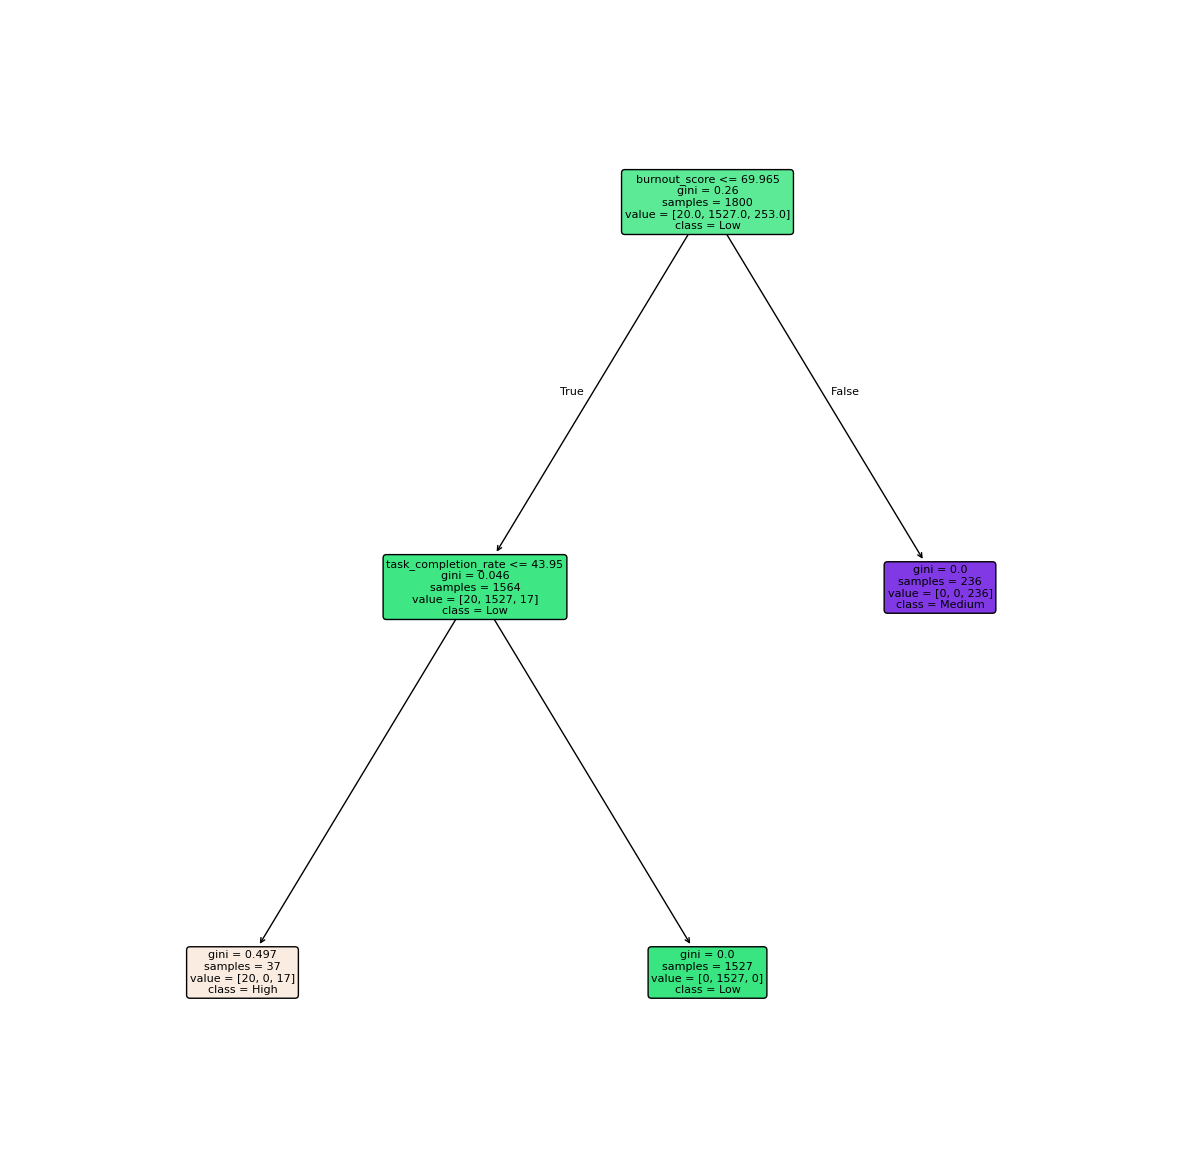

In [34]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,15))
plot_tree(modelTree, feature_names=X.columns.values, class_names=labelencoder.classes_, rounded=True, filled=True, fontsize=8)
plt.show()


# 5. Evaluación del mejor modelo hiperparametrizado


In [35]:
#División 70-30
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=3) #Muestreo estratificado
modelTree.fit(X_train, Y_train)
Y_pred = modelTree.predict(X_test)


In [36]:
#Matriz de confusion
matriz=confusion_matrix(Y_test, Y_pred)
matriz


array([[  6,   0,   0],
       [  0, 458,   0],
       [  8,   0,  68]])

In [37]:
#P, R, F1
print(classification_report(Y_test, Y_pred, target_names=labelencoder.classes_))


              precision    recall  f1-score   support

        High       0.43      1.00      0.60         6
         Low       1.00      1.00      1.00       458
      Medium       1.00      0.89      0.94        76

    accuracy                           0.99       540
   macro avg       0.81      0.96      0.85       540
weighted avg       0.99      0.99      0.99       540



# **Conclusión del mejor modelo**

El mejor modelo hiperparametrizado es un Árbol de Decisión con `criterion='gini'`, `max_depth=2` y `min_samples_leaf=2`. El `f1_macro` promedio obtenido con GridSearchCV fue 0.9059, superior al promedio inicial del Árbol de Decisión.

En la evaluación 70-30, el modelo alcanza una exactitud de 0.99 y un `f1_macro` macro promedio de 0.85. La clase `Low` se predice muy bien por tener mayor cantidad de registros. La clase `Medium` también presenta buen desempeño, con `f1-score` de 0.94. La clase `High` debe interpretarse con cuidado porque tiene pocos registros; aunque el recall es 1.00, la precisión es 0.43 por algunos casos `Medium` clasificados como `High`.

El modelo se considera adecuado para el despliegue académico porque combina buena calidad predictiva, facilidad de interpretación y compatibilidad con una interfaz gráfica sencilla. Además, no presenta evidencia de overfitting fuerte al comparar las métricas de entrenamiento y prueba en validación cruzada.


# 6. Guardar el modelo


In [38]:
#Modelo final
modelTree.fit(X, Y) #100%


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

In [39]:
#Se guarda el modelo
import pickle
filename = 'modelo_burnout.pkl'
variables=X.columns._values
pickle.dump([modelTree,labelencoder,variables,min_max_scaler], open(filename, 'wb'))
